# Assignment 4: Decision Tree
 Description: This assignment involves preprocessing the Titanic dataset, encoding categorical features, analyzing relationships using a correlation heatmap, and building and evaluating a decision tree model to predict passenger survival.

Group 2: Cathy Lee, Evan Gray, Aviral Gusain

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Part 1: Data Preprocessing

* #### Initil Exploration
1.  Load the dataset. Print the shape and the first 5 rows.

In [22]:
df = pd.read_excel("titanic.xlsx")

print("Shape:", df.shape)
display(df.head())

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,2,"Brown, Miss. Mabel",female,61.0,0,1,797787,7.6093,NaN,S
1,2,0,3,"Young, Miss. Nellie",female,20.9,1,1,705364,3.1700,D119,S
2,3,0,3,"Allen, Mr. George",male,40.5,0,0,542486,4.6967,NaN,S
3,4,0,3,"King, Miss. Edith",female,NaN,0,0,920156,44.1734,NaN,S
4,5,0,1,"Wilson, Mr. Thomas",male,48.6,0,0,STON/O2. 480198,243.1897,NaN,S


2. Print the data types and check for missing values in every column. In a 
markdown cell, report which columns have missing values and how many are missing in 
each. 

In [23]:
print("Data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Missing Values Report

The columns with missing values are:

- `Age`: 177 missing values
- `Cabin`: 687 missing values
- `Embarked`: 2 missing values

3. For each column that has missing values, decide how to handle it:
    1) fill it in 
    2) or drop the column entirely. In a markdown cell, explain why you chose each strategy.  

In [24]:
# Fill Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column
df = df.drop(columns=["Cabin"])

### Missing Value Handling

I filled `Age` with the median because it is a numerical feature and may contain outliers, so the median is more robust than the mean.

I dropped `Cabin` because it has 687 missing values, which is a large portion of the dataset. Filling it would introduce too much noise.

I filled `Embarked` with the mode because it is a categorical feature with only 2 missing values, so using the most common category is reasonable and does not distort the data.

4. Verify that no missing values remain. Print the missing value counts after your 
changes to confirm. 

In [25]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


* #### Encode Categorical Features 
1.  Identify the string columns that can be meaningfully encoded. Apply the 
appropriate encoding method to each: 
    1) Binary columns with exactly two values to convert to 0/1.
    2) Columns with more than two categories to create one-hot encoded columns. 

In [26]:
print("String columns before encoding:")
print(df.select_dtypes(include="object").columns)

for col in df.select_dtypes(include="object").columns:
    print(f"\n{col} unique values: {df[col].nunique()}")

# Binary encode Sex
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# One-hot encode Embarked
df = pd.get_dummies(df, columns=["Embarked"], dtype=int)

print("\nColumns after encoding:")
print(df.columns)

display(df.head())

String columns before encoding:
Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='str')

Name unique values: 658

Sex unique values: 2

Ticket unique values: 891

Embarked unique values: 3

Columns after encoding:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='str')


C:\Users\gusai\AppData\Local\Temp\ipykernel_95672\51586417.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns)
C:\Users\gusai\AppData\Local\Temp\ipykernel_95672\51586417.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,1,2,"Brown, Miss. Mabel",1,61.0,0,1,797787,7.6093,0,0,1
1,2,0,3,"Young, Miss. Nellie",1,20.9,1,1,705364,3.1700,0,0,1
2,3,0,3,"Allen, Mr. George",0,40.5,0,0,542486,4.6967,0,0,1
3,4,0,3,"King, Miss. Edith",1,30.0,0,0,920156,44.1734,0,0,1
4,5,0,1,"Wilson, Mr. Thomas",0,48.6,0,0,STON/O2. 480198,243.1897,0,0,1


2. In a markdown cell, explain which method you used for each column and why 
one-hot encoding is preferred over label encoding for a nominal column like Embarked. 

I encoded `Sex` using binary encoding because it has exactly two categories, `male` and `female`, so converting them to 0 and 1 is appropriate and preserves the meaning of the feature.

I encoded `Embarked` using one-hot encoding because it has more than two categories (`S`, `C`, and `Q`) and is a nominal feature. One-hot encoding is preferred over label encoding for `Embarked` because label encoding would assign numbers such as 0, 1, and 2, which incorrectly suggests an order or distance between categories. The embarkation ports are just category labels, not ranked values, so one-hot encoding avoids introducing false relationships.

3. Drop the columns that cannot be meaningfully encoded. In a markdown cell, 
explain the reason for dropping each one. It might be different reasons even if the action 
is the same. 

In [27]:
df = df.drop(columns=["Name", "Ticket", "PassengerId"])

print("Columns after dropping unhelpful features:")
print(df.columns)

display(df.head())

Columns after dropping unhelpful features:
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='str')


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,2,1,61.0,0,1,7.6093,0,0,1
1,0,3,1,20.9,1,1,3.1700,0,0,1
2,0,3,0,40.5,0,0,4.6967,0,0,1
3,0,3,1,30.0,0,0,44.1734,0,0,1
4,0,1,0,48.6,0,0,243.1897,0,0,1


### Dropped Columns

I dropped `Name` because it is free text and does not have a simple, meaningful encoding for this assignment.

I dropped `Ticket` because it contains irregular alphanumeric values that do not follow a consistent structure that would make straightforward encoding useful.

I dropped `PassengerId` because it is only a unique identifier for each passenger and does not represent a real predictive feature.

* #### Heatmap Visualization 
1.  Generate a correlation heatmap for all features in your DataFrame (including 
Survived). Use seaborn.heatmap() with annot=True. Make the figure large enough to read 
clearly. 

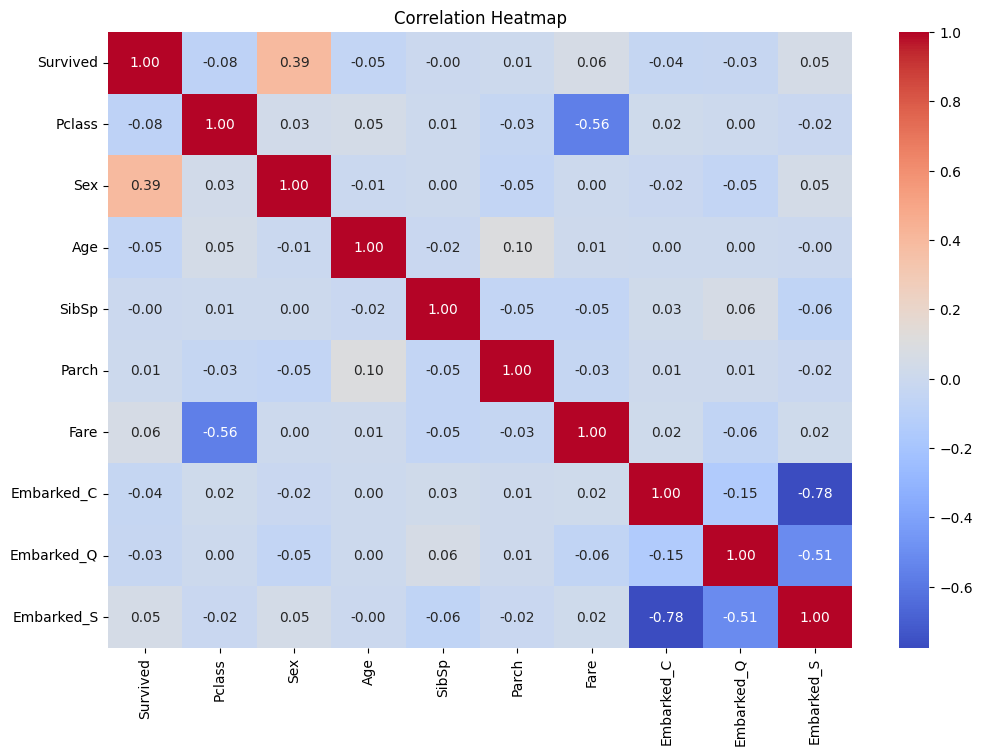

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

2.  In a markdown cell, answer the following three questions, you must reference 
specific column names and numeric correlation values from your heatmap: 
    1) Report the two largest absolute correlations with Survived, including their exact 
values and signs. What does the sign of each tell you about the relationship with 
survival? 
    2) Do you observe any two features that are strongly correlated with each other rather 
than with Survived? Report the pair and the correlation value. What might explain 
this? 

### Heatmap Analysis

The two largest absolute correlations with `Survived` are:

1. `Sex` with a correlation of `+0.39`
2. `Pclass` with a correlation of `-0.08`

The positive sign for `Sex` means that higher values of this feature are associated with a greater chance of survival. Since `female = 1` and `male = 0`, this indicates that female passengers were more likely to survive.

The negative sign for `Pclass` means that higher class numbers are associated with a lower chance of survival. Since larger values represent lower ticket classes, this suggests that passengers in lower classes were less likely to survive.

A strong correlation between two features (not involving `Survived`) appears between `Embarked_C` and `Embarked_S`, with a correlation of `-0.78`. This occurs because these are one-hot encoded columns from the same original categorical variable, so when one is 1, the others are usually 0.

Another strong pair is `Pclass` and `Fare`, with a correlation of `-0.56`, which makes sense because passengers in higher classes generally paid higher fares.

* #### Prepare Features and Split 
1.  Split your data into training (80%) and testing (20%) sets using stratify on the 
target variable and random_state=42. 

In [29]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

2. Print the shape of all four arrays (X_train, X_test, y_train, y_test). 

In [30]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 9)
X_test shape: (179, 9)
y_train shape: (712,)
y_test shape: (179,)


3. Show histograms for at least two features before and after all your corrections. 
Comment on how the distributions changed. 

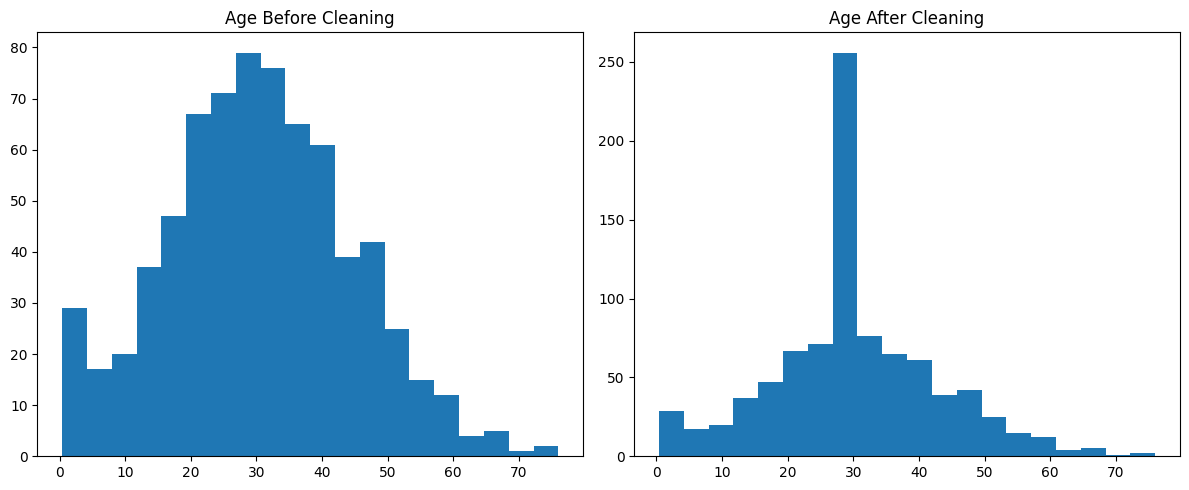

In [31]:
# Reload original data for comparison
raw_df = pd.read_excel("titanic.xlsx")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age before cleaning
axes[0].hist(raw_df["Age"].dropna(), bins=20)
axes[0].set_title("Age Before Cleaning")

# Age after cleaning
axes[1].hist(df["Age"], bins=20)
axes[1].set_title("Age After Cleaning")

plt.tight_layout()
plt.show()

### Distribution Changes

The distribution of `Age` remains similar after cleaning because missing values were filled using the median, which preserves the overall shape of the data.

There may be a slight increase around the median value since missing values were replaced with that value, but no major distortion is introduced.

4. Verify that all features are numerical by printing X_train.dtypes. In a 
markdown cell, confirm that no string or Boolean columns remain. If any do, fix them 
now and explain what you have changed. 

In [32]:
print(X_train.dtypes)

Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_C      int32
Embarked_Q      int32
Embarked_S      int32
dtype: object


#### Final Feature Type Check

All columns in `X_train` are numerical. There are no remaining string or Boolean columns, so the dataset is fully prepared for use with the DecisionTreeClassifier.

### Part 2: Build Decision Tree

* #### Train an Unpruned Tree 
1. Train a DecisionTreeClassifier with criterion='entropy', random_state=42, and 
no other constraints (default parameters).  

In [33]:
dt = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

2.  Report the training accuracy and testing accuracy. Print both values clearly. 

In [34]:
print("Training Accuracy: ", accuracy_score(y_train, dt.predict(X_train)))
print("Testing Accuracy: ", accuracy_score(y_test, dt.predict(X_test)))

Training Accuracy:  0.9985955056179775
Testing Accuracy:  0.7541899441340782


* #### Analyze the Overfitting
1. In a markdown cell, compare the training and testing accuracy. What do you 
observe? Is the model overfitting? How can you tell?

The training accuracy is near perfect and the testing accuracy is quite low. This implies that the model is heavily overfitting to the training data. This is becuase it is perfectly guessing the training data and sometimes guessing the testing data, which is exactly what overfitting is.

2) Print the depth of your unpruned tree using tree.get_depth() and the total 
number of leaves using tree.get_n_leaves(). In a markdown cell, comment on whether 
these numbers seem reasonable for a dataset of this size. 

In [35]:
print("Unpruned depth:", dt.get_depth())
print("Unpruned number of leaves:", dt.get_n_leaves())

Unpruned depth: 26
Unpruned number of leaves: 130


This depth and number of leaves is too high for a dataset of this size. This could be the reason for the overfitting we have observed.

3) Create a plot showing training accuracy vs. testing accuracy for max_depth 
values from 1 to 20. Use a line plot with two clearly labeled lines, axis labels, a legend, 
and a title.

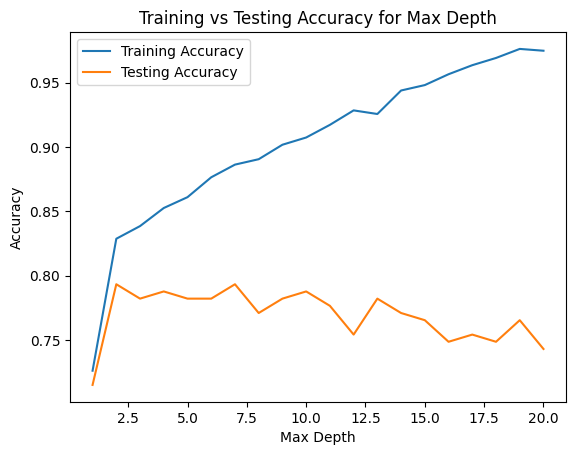

In [36]:
maxDepths = list(range(1, 21))
trainAccuracies = []
testAccuracies = []

# Loop over max depths
for depth in maxDepths:
  currentDt = DecisionTreeClassifier(max_depth = depth, criterion = 'entropy', random_state = 42)
  currentDt.fit(X_train, y_train)

  # Get Accuracies
  trainAccuracies.append(accuracy_score(y_train, currentDt.predict(X_train)))
  testAccuracies.append(accuracy_score(y_test, currentDt.predict(X_test)))

# Plot data
plt.figure()
plt.plot(maxDepths, trainAccuracies, label = "Training Accuracy")
plt.plot(maxDepths, testAccuracies, label = "Testing Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy for Max Depth")
plt.legend()
plt.show()

4) In a markdown cell below the plot, describe what pattern you observe and at 
what depth the gap between training and testing accuracy starts to widen noticeably.

As the max depth increases the training accuracy increases but the testing accuracy decreases. This decrease seems to begin around a max depth of 8, since it never gets close to 80% testing accuracy again.

5) In a markdown cell: When max_depth=1, the tree is very shallow. Is this 
model more likely to suffer from underfitting or overfitting? What about when 
max_depth=20? Connect your answers to what you see in your plot above.

When the max_depth = 1 the model is more likely to suffer from underfitting, since it doesnt take into account much of the data. In addition the plot testing and training accuracy is basiclly guessing in the plot, which implies underfitting.  
While on the otherhand when max_depth = 20 the model is much more likely to suffer from overfitting, since in the plot the model is way better at guessing the training data.

6. Based on your plot, what range of max_depth values appears to give the best 
balance between training and testing performance? Justify your answer. 

Max_depth from 2 to 7 appears to give the best balance between training and testing performance. In this range testing accurancy stays around is ~80% and then begins to drop afterwords. In addition starting at 2 training accuracy goes from ~80% to ~90%. So in this range you will get high training accuracy without losing testing accuracy.

* #### Confusion Matrix

1. Generate and display a confusion matrix for the untuned tree on the test set.

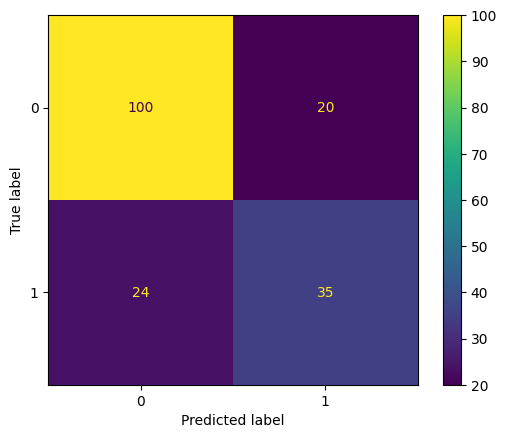

In [37]:
cm = confusion_matrix(y_test, dt.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = dt.classes_)
disp.plot()

2. In a markdown cell, interpret the confusion matrix: 
    1) How many True Negatives and True Positives did the model produce? 
    2) Which error type is more common, False Positives or False Negatives? 
    3) In the Titanic context, what is the real-world consequence of each error type? 
Which would you consider more costly and why? 

True Negatives: 100
True Positives: 35

False negatives were more common, since it had 24 and false positives have 20.

I consider false positives to be more costly, since it fasly predicts that the person survived. This may mislead a person into false safetly, that could then lead to more accidents/deaths. Where as a false negative will just cause the person to be overlly cautious for no reason. Though if this was being used to find survivers from the crash, then false negatives could be worse.


* #### Effect of Training Sample Size

1) Using your unpruned tree, train the model on increasing fractions of the 
training set: 10%, 25%, 50%, 75%, and 100%. For each fraction, record:
    1) training accuracy
    2) testing accuracy
    3) averaged training time.  
    Create a figure with two subplots: one showing training and testing accuracy vs. training set size, and another 
showing training time vs. training set size.
Label all axes and include legends. 

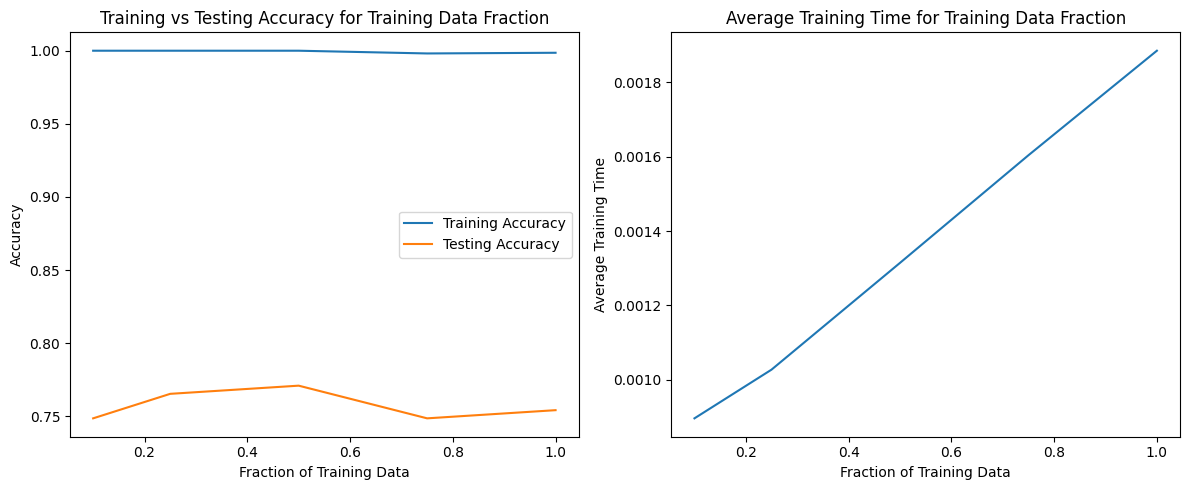

In [38]:
fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
trainAccuracies = []
testAccuracies = []
averageTrainTime = []

for frac in fractions:
  # Get subset of training data
  if(frac < 1.0):
    XSubset, XUnused, ySubset, yUnused = train_test_split(X_train, y_train, train_size = frac, stratify = y_train, random_state = 42)
  else:
    XSubset, ySubset = X_train, y_train

  startTime = time.time()
  for _ in range(200):
    # Train
    subDt = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
    subDt.fit(XSubset, ySubset)
  
  # Get average training time
  averageTrainTime.append((time.time() - startTime) / 200)

  # Accuracy
  trainAccuracies.append(accuracy_score(ySubset, subDt.predict(XSubset)))
  testAccuracies.append(accuracy_score(y_test, subDt.predict(X_test)))

# Accuracy and Time subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fractions, trainAccuracies, label = "Training Accuracy")
axes[0].plot(fractions, testAccuracies, label = "Testing Accuracy")
axes[0].set_xlabel("Fraction of Training Data")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training vs Testing Accuracy for Training Data Fraction")
axes[0].legend()
axes[1].plot(fractions, averageTrainTime)
axes[1].set_xlabel("Fraction of Training Data")
axes[1].set_ylabel("Average Training Time")
axes[1].set_title("Average Training Time for Training Data Fraction")
plt.tight_layout()
plt.show()

2) In a markdown cell, analyze your plots. How does increasing training set size 
affect accuracy? Does the gap between training and testing accuracy shrink or grow? 
How does training time scale?  

As the training set size increases the testing accuracy starts to increase, and then starts to decrease after about 50%. This is probably due to overfitting as the dataset gets larger. Training accuracy doesnt change from data set size, so therefore the gap starts to shrink and then starts growing.  

Training time goes up as the data set size goes up, with it being about three times slower than at first.

### Part 3: Tuning max_depth with 5-Fold Cross-Validation (CV) 

* #### Find the Best max_depth 

1. You will loop over candidate depth values and use cross_val_score() to 
evaluate each one. It returns an array of 5 accuracy scores, one per fold. Record both the 
mean and the standard deviation of those 5 scores for each depth. 

In [39]:
maxDepths = list(range(1, 21))
meanCVAccuracies = []
stdCVAccuracies = []
cvTimes = []

for depth in maxDepths:
    currentDt = DecisionTreeClassifier(
        max_depth=depth,
        criterion='entropy',
        random_state=42
    )

    startTime = time.time()
    scores = cross_val_score(currentDt, X_train, y_train, cv=5, scoring='accuracy')
    endTime = time.time()

    meanCVAccuracies.append(scores.mean())
    stdCVAccuracies.append(scores.std())
    cvTimes.append(endTime - startTime)

bestIndex = np.argmax(meanCVAccuracies)
bestDepth = maxDepths[bestIndex]

print("Best max_depth:", bestDepth)
print("Best mean CV accuracy:", meanCVAccuracies[bestIndex])
print("Best std CV accuracy:", stdCVAccuracies[bestIndex])

Best max_depth: 7
Best mean CV accuracy: 0.8300305328474342
Best std CV accuracy: 0.014600265953759456


2. Create a figure with two subplots (Label all axes, include titles, and add a 
legend where appropriate) 
    1) Subplot 1: Mean CV accuracy vs. max_depth with error bars representing the 
standard deviation.  
    2) Subplot 2: Cross-validation time vs. max_depth. 

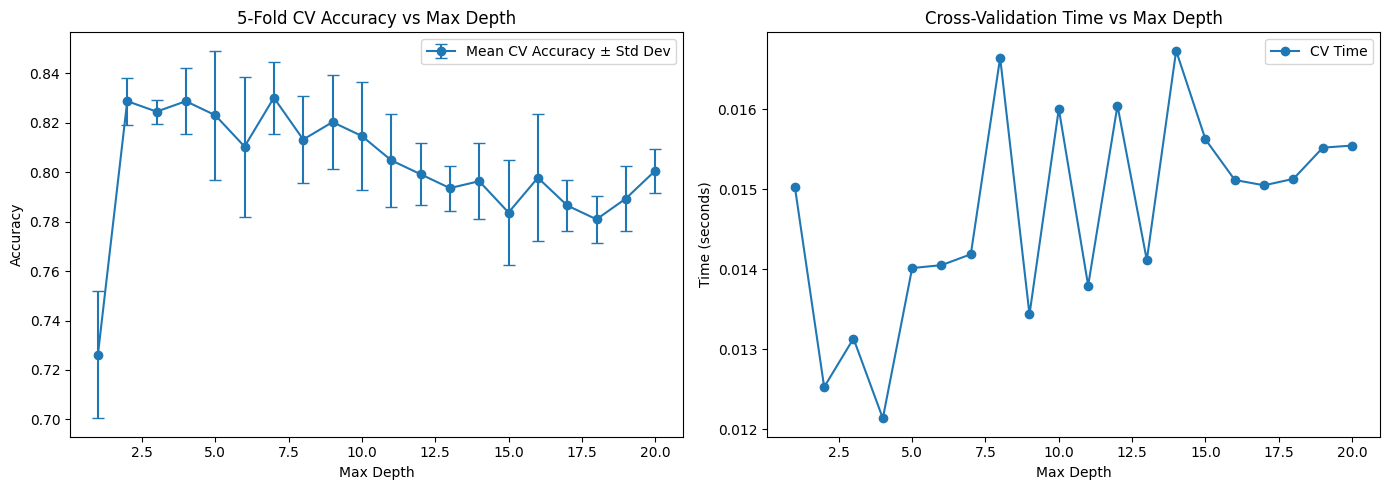

Best max_depth: 7
Best mean CV accuracy: 0.8300305328474342


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Mean CV accuracy with error barss
axes[0].errorbar(
    maxDepths,
    meanCVAccuracies,
    yerr=stdCVAccuracies,
    fmt='-o',
    capsize=4,
    label='Mean CV Accuracy ± Std Dev'
)
axes[0].set_xlabel("Max Depth")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("5-Fold CV Accuracy vs Max Depth")
axes[0].legend()

# Subplot 2: CV time vs max_depth
axes[1].plot(maxDepths, cvTimes, marker='o', label='CV Time')
axes[1].set_xlabel("Max Depth")
axes[1].set_ylabel("Time (seconds)")
axes[1].set_title("Cross-Validation Time vs Max Depth")
axes[1].legend()

plt.tight_layout()
plt.show()

# identify the best max_depth based on the highest mean CV accuracy. and print
bestIndex = np.argmax(meanCVAccuracies)
bestDepth = maxDepths[bestIndex]
print("Best max_depth:", bestDepth)
print("Best mean CV accuracy:", meanCVAccuracies[bestIndex])

3. In a markdown cell, identify the best max_depth based on the highest mean 
CV accuracy. Then answer: 
    1) If multiple depths give very similar mean CV accuracy, which would you prefer 
and why? Consider both the mean and the standard deviation. 
    2) Print the best max_depth with its mean CV accuracy and standard deviation. 

The best `max_depth` based on the highest mean 5-fold cross-validation accuracy is **7**.

Its mean CV accuracy is approximately **0.83**, and its standard deviation is about **0.015**.

Several depth values between about **2 and 7** produce very similar cross-validation accuracies. When multiple depths perform similarly, I would usually prefer the **smaller depth** because it results in a simpler model that is easier to interpret and less likely to overfit the training data. I would also consider the **standard deviation**, since a smaller standard deviation indicates the model performs more consistently across the different cross-validation folds. However, since **depth 7** gives the highest mean CV accuracy in this experiment, it is selected as the best `max_depth`.

* #### Evaluate the Final Model on the Test Set 

1. Now that you have selected the best max_depth, retrain the final model on the 
full X_train and evaluate once on X_test. Report training accuracy and testing accuracy. 

In [41]:
tunedDt = DecisionTreeClassifier(
    max_depth=bestDepth,
    criterion='entropy',
    random_state=42
)
tunedDt.fit(X_train, y_train)

tunedTrainAccuracy = accuracy_score(y_train, tunedDt.predict(X_train))
tunedTestAccuracy = accuracy_score(y_test, tunedDt.predict(X_test))

print("Tuned model max_depth:", bestDepth)
print("Tuned Training Accuracy:", tunedTrainAccuracy)
print("Tuned Testing Accuracy:", tunedTestAccuracy)

Tuned model max_depth: 7
Tuned Training Accuracy: 0.8862359550561798
Tuned Testing Accuracy: 0.7932960893854749


2) Generate and display confusion matrix for both tuned and untuned model 
(already generated in 2.3) on the test set. In a markdown cell, compare the confusion 
matrices. Did tuning max_depth reduce any specific type of error? 

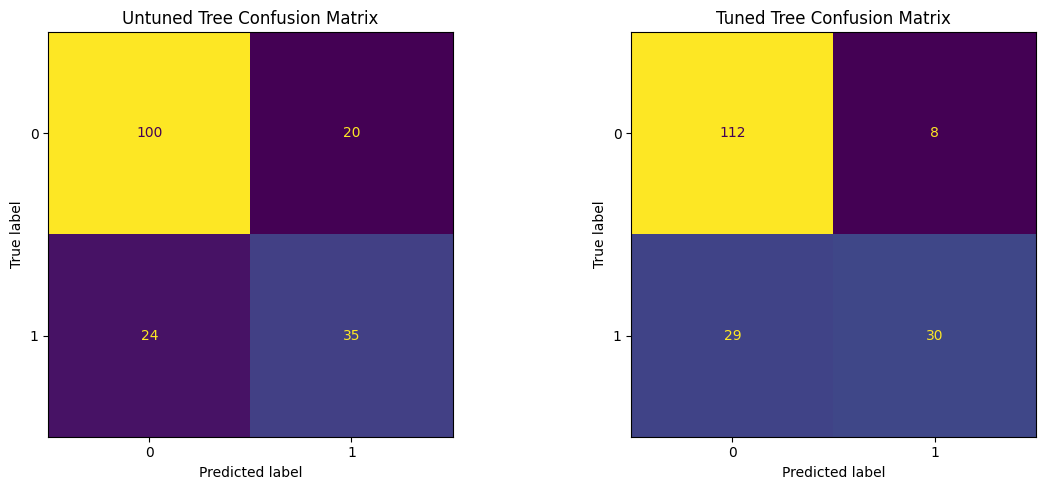

Untuned confusion matrix:
 [[100  20]
 [ 24  35]]
Tuned confusion matrix:
 [[112   8]
 [ 29  30]]


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Untuned confusion matrix
cmUntuned = confusion_matrix(y_test, dt.predict(X_test))
dispUntuned = ConfusionMatrixDisplay(confusion_matrix=cmUntuned, display_labels=dt.classes_)
dispUntuned.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Untuned Tree Confusion Matrix")

# Tuned confusion matrix
cmTuned = confusion_matrix(y_test, tunedDt.predict(X_test))
dispTuned = ConfusionMatrixDisplay(confusion_matrix=cmTuned, display_labels=tunedDt.classes_)
dispTuned.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Tuned Tree Confusion Matrix")

plt.tight_layout()
plt.show()

print("Untuned confusion matrix:\n", cmUntuned)
print("Tuned confusion matrix:\n", cmTuned)

The tuned model changed the types of errors made on the test set. In the untuned model, there were **20 false positives and 24 false negatives**. After tuning the max_depth, the number of false positives decreased to **8**, which means the model became better at correctly identifying passengers who did not survive. However, the number of false negatives **increased from 24 to 29**, meaning the model missed more actual survivors. In other words, tuning reduced false positives but increased false negatives, making the model slightly more conservative when predicting survival.

 3) Create a summary comparison table with columns: Max_depth | Mean CV Accuracy | Test Accuracy | Leaves | Time

In [43]:
summaryTable = pd.DataFrame({
    "Max_depth": ["Untuned (None)", bestDepth],
    "Mean CV Accuracy": [np.nan, meanCVAccuracies[bestIndex]],
    "Test Accuracy": [
        accuracy_score(y_test, dt.predict(X_test)),
        tunedTestAccuracy
    ],
    "Leaves": [
        dt.get_n_leaves(),
        tunedDt.get_n_leaves()
    ],
    "Time": [
        np.nan,
        cvTimes[bestIndex]
    ]
})

summaryTable

,Max_depth,Mean CV Accuracy,Test Accuracy,Leaves,Time
0,Untuned (None),NaN,0.754190,130,NaN
1,7,0.830031,0.793296,37,0.014186


4. Comment on the differences: Did the tuned model reduce overfitting? How does the 
number of leaves compare? How close is the mean CV accuracy to the final test 
accuracy?

The tuned model did reduce overfitting. The untuned tree achieved almost perfect training accuracy, but its test accuracy was only about **0.754**, which suggests the model was overfitting the training data. After tuning the model with `max_depth` = 7, the test accuracy improved to about **0.793**, indicating better generalization to unseen data.

The number of leaves also decreased significantly. The untuned tree had 130 leaves, while the tuned model had only 37 leaves. This shows that the tuned model is much simpler and less likely to memorize the training data.

The mean cross-validation accuracy for the tuned model was about **0.830**, while the final test accuracy was about **0.793**. These values are reasonably close, which suggests that cross-validation provided a good estimate of how the tuned model would perform on unseen data.

* ####  Visualize the Tuned Tree

1. Visualize your tuned and untuned decision trees. Set feature_names to your 
column names.  

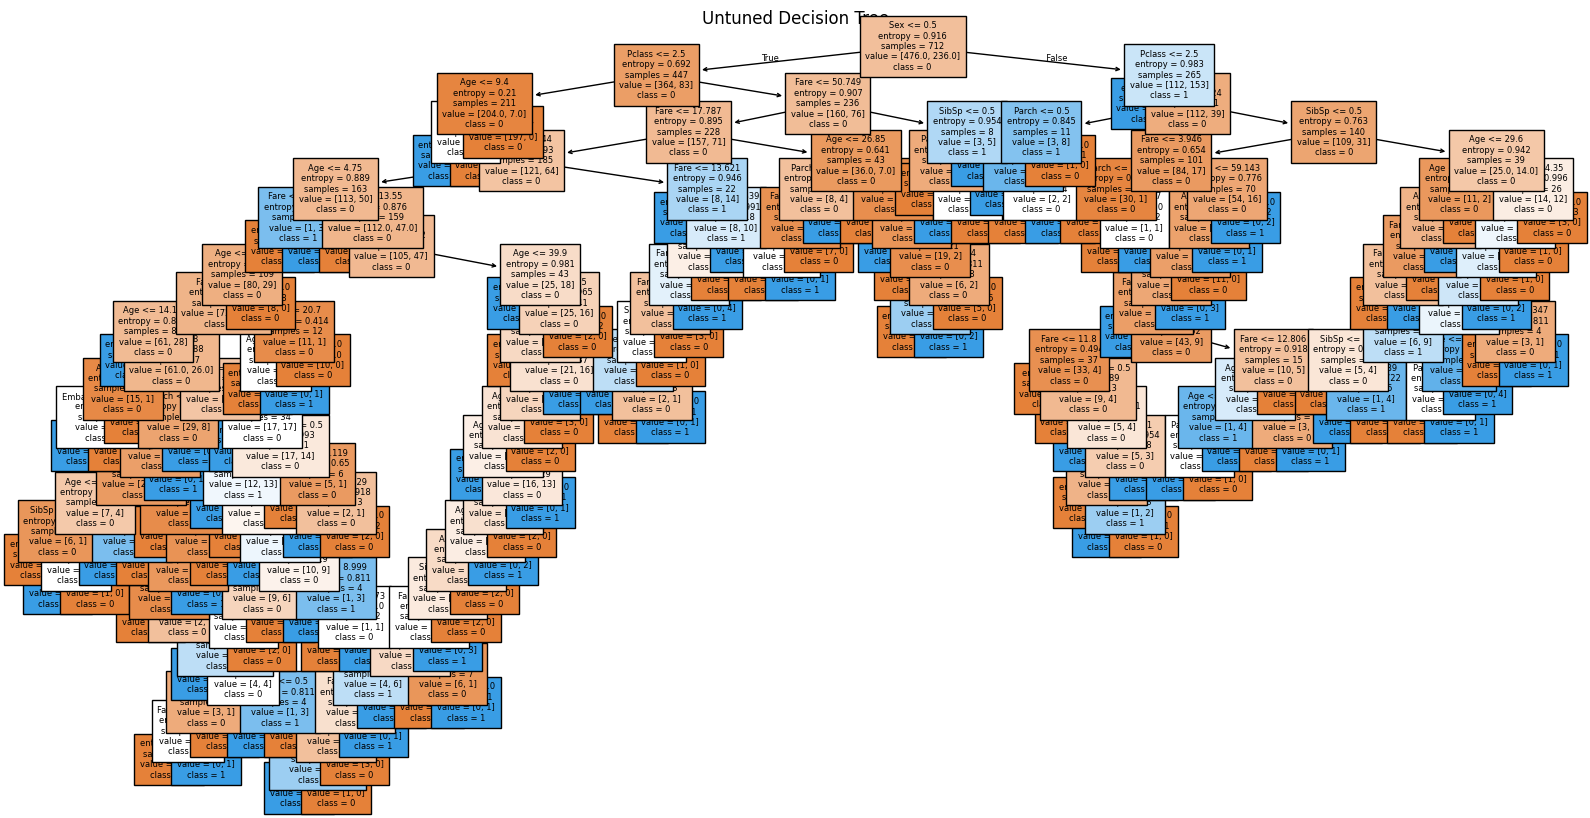

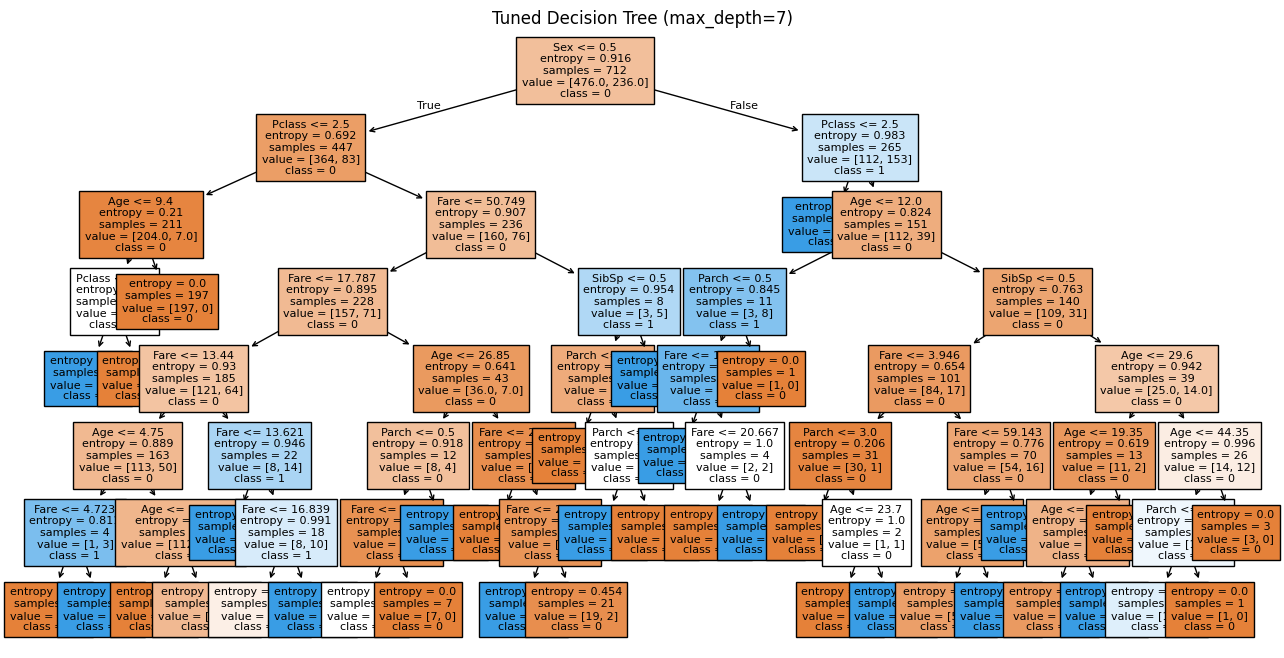

In [49]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=[str(c) for c in dt.classes_],
    filled=True,
    fontsize=6
)
plt.title("Untuned Decision Tree")
plt.show()

plt.figure(figsize=(16, 8))
plot_tree(
    tunedDt,
    feature_names=X.columns,
    class_names=[str(c) for c in tunedDt.classes_],
    filled=True,
    fontsize=8
)
plt.title(f"Tuned Decision Tree (max_depth={bestDepth})")
plt.show()

* ####  Member Contributions

1. List each member's name and specific contribution.

Cathy Lee: Part 1, 
Evan Gray: Part 2, 
Aviral Gusain: Part 3, 

* ####  AI tool disclosure:

1. List any AI tools used and how. If you have not use any AI, you also need to clearly confirm that.

Cathy Lee: No AI was used, Evan Gray: No AI was used, Aviral Gusain: No AI was used